# Breast Cancer Survival Prediction

<img src='https://images.squarespace-cdn.com/content/v1/64011f10da897a3162ea8900/f9f658bb-f0c9-48c3-8fd7-c55044b95164/breast-cancer-awareness-2022-11-14-01-58-45-utc.jpg'>

🇹🇷 Türkçe
Bu çalışmada, meme kanseri hastalarına ait klinik ve demografik veriler kullanılarak hastaların sağkalım durumlarının (ölüm/yaşam) sınıflandırılması amaçlanmıştır.

🇬🇧 English
In this study, clinical and demographic data of breast cancer patients were utilized to classify patient survival outcomes (deceased vs. alive).

In [1]:
import pandas as pd
pd.set_option('display.max_columns',100)

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [2]:
df=pd.read_csv('BRCA.csv')

In [3]:
df.head()

,Patient_ID,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status
0,TCGA-D8-A1XD,36.0,FEMALE,0.080353,0.42638,0.54715,0.273680,III,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Modified Radical Mastectomy,15-Jan-17,19-Jun-17,Alive
1,TCGA-EW-A1OX,43.0,FEMALE,-0.420320,0.57807,0.61447,-0.031505,II,Mucinous Carcinoma,Positive,Positive,Negative,Lumpectomy,26-Apr-17,09-Nov-18,Dead
2,TCGA-A8-A079,69.0,FEMALE,0.213980,1.31140,-0.32747,-0.234260,III,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,08-Sep-17,09-Jun-18,Alive
3,TCGA-D8-A1XR,56.0,FEMALE,0.345090,-0.21147,-0.19304,0.124270,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Modified Radical Mastectomy,25-Jan-17,12-Jul-17,Alive
4,TCGA-BH-A0BF,56.0,FEMALE,0.221550,1.90680,0.52045,-0.311990,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,06-May-17,27-Jun-19,Dead


In [4]:
df.tail()

,Patient_ID,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status
336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341 entries, 0 to 340
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Patient_ID          334 non-null    object 
 1   Age                 334 non-null    float64
 2   Gender              334 non-null    object 
 3   Protein1            334 non-null    float64
 4   Protein2            334 non-null    float64
 5   Protein3            334 non-null    float64
 6   Protein4            334 non-null    float64
 7   Tumour_Stage        334 non-null    object 
 8   Histology           334 non-null    object 
 9   ER status           334 non-null    object 
 10  PR status           334 non-null    object 
 11  HER2 status         334 non-null    object 
 12  Surgery_type        334 non-null    object 
 13  Date_of_Surgery     334 non-null    object 
 14  Date_of_Last_Visit  317 non-null    object 
 15  Patient_Status      321 non-null    object 
dtypes: float

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,334.0,58.886228,12.961212,29.00000,49.000000,58.000000,68.000000,90.0000
Protein1,334.0,-0.029991,0.563588,-2.34090,-0.358888,0.006129,0.343598,1.5936
Protein2,334.0,0.946896,0.911637,-0.97873,0.362173,0.992805,1.627900,3.4022
Protein3,334.0,-0.090204,0.585175,-1.62740,-0.513748,-0.173180,0.278353,2.1934
Protein4,334.0,0.009819,0.629055,-2.02550,-0.377090,0.041768,0.425630,1.6299


In [7]:
df.isnull().sum()

Patient_ID             7
Age                    7
Gender                 7
Protein1               7
Protein2               7
Protein3               7
Protein4               7
Tumour_Stage           7
Histology              7
ER status              7
PR status              7
HER2 status            7
Surgery_type           7
Date_of_Surgery        7
Date_of_Last_Visit    24
Patient_Status        20
dtype: int64

In [8]:
df = df.dropna(how='any')

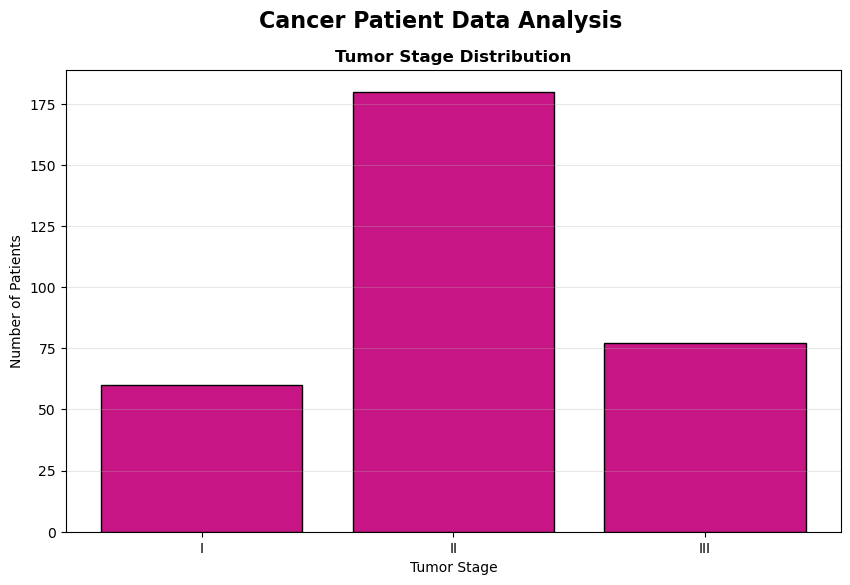

In [71]:
# Tumor Stage Distribution
fig = plt.figure(figsize=(10, 6))
fig.suptitle('Cancer Patient Data Analysis', fontsize=16, fontweight='bold')
stage_counts = df['Tumour_Stage'].value_counts().sort_index()
plt.bar(stage_counts.index, stage_counts.values, color='#C71585', edgecolor='black')
plt.title('Tumor Stage Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Tumor Stage')
plt.ylabel('Number of Patients')
plt.grid(axis='y', alpha=0.3)

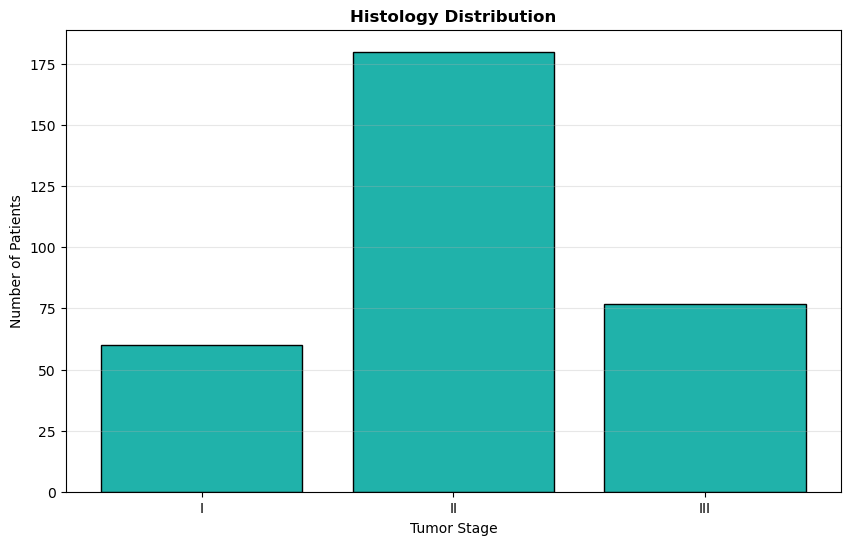

In [68]:
#Histology Distribution
fig = plt.figure(figsize=(10, 6))
stage_counts = df['Tumour_Stage'].value_counts().sort_index()
plt.bar(stage_counts.index, stage_counts.values, color='#20B2AA', edgecolor='black')
plt.title('Histology Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Tumor Stage')
plt.ylabel('Number of Patients')
plt.grid(axis='y', alpha=0.3)

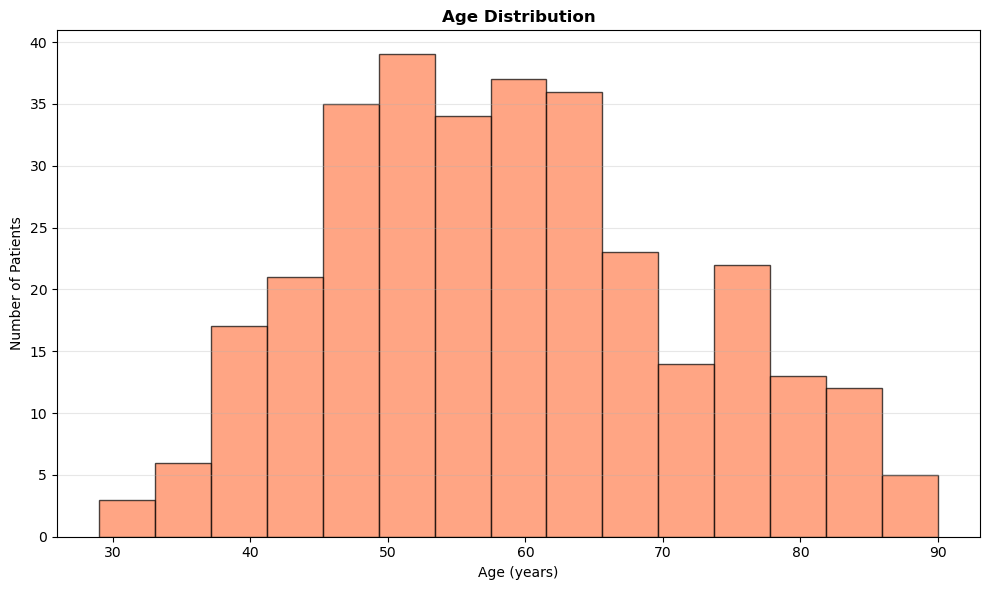

In [72]:
#Age Distribution
plt.figure(figsize=(10, 6))
plt.hist(df['Age'].dropna(), bins=15, color='coral', edgecolor='black', alpha=0.7)
plt.title('Age Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Age (years)')
plt.ylabel('Number of Patients')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

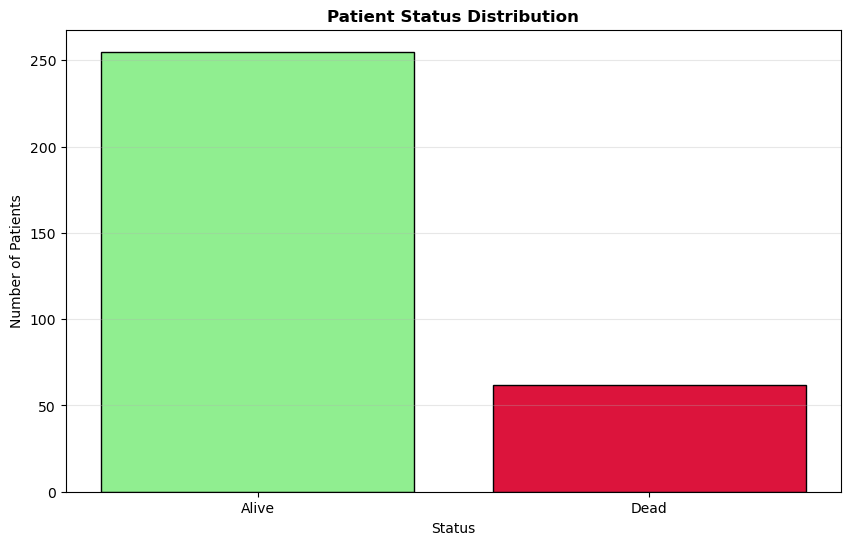

In [11]:
# Patient Status Distribution
fig = plt.figure(figsize=(10, 6))
status_counts = df['Patient_Status'].value_counts()
colors = ['#90EE90', '#DC143C']
plt.bar(status_counts.index, status_counts.values, color=colors, edgecolor='black')
plt.title('Patient Status Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Status')
plt.ylabel('Number of Patients')
plt.grid(axis='y', alpha=0.3)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317 entries, 0 to 333
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Patient_ID          317 non-null    object 
 1   Age                 317 non-null    float64
 2   Gender              317 non-null    object 
 3   Protein1            317 non-null    float64
 4   Protein2            317 non-null    float64
 5   Protein3            317 non-null    float64
 6   Protein4            317 non-null    float64
 7   Tumour_Stage        317 non-null    object 
 8   Histology           317 non-null    object 
 9   ER status           317 non-null    object 
 10  PR status           317 non-null    object 
 11  HER2 status         317 non-null    object 
 12  Surgery_type        317 non-null    object 
 13  Date_of_Surgery     317 non-null    object 
 14  Date_of_Last_Visit  317 non-null    object 
 15  Patient_Status      317 non-null    object 
dtypes: float64(5)

In [13]:
df.Gender.value_counts()

Gender
FEMALE    313
MALE        4
Name: count, dtype: int64

In [14]:
df.Tumour_Stage.value_counts()

Tumour_Stage
II     180
III     77
I       60
Name: count, dtype: int64

In [15]:
df.Histology.value_counts()

Histology
Infiltrating Ductal Carcinoma     224
Infiltrating Lobular Carcinoma     81
Mucinous Carcinoma                 12
Name: count, dtype: int64

In [16]:
#for c in df: print(c, df[c].unique())

In [17]:
#Feature Engineering

In [18]:
# Date columns to datetime
df['Date_of_Surgery'] = pd.to_datetime(df['Date_of_Surgery'], format='%d-%b-%y')
df['Date_of_Last_Visit'] = pd.to_datetime(df['Date_of_Last_Visit'], format='%d-%b-%y')

In [19]:
# Follow-up duration
df['Follow_up_Days'] = (df['Date_of_Last_Visit'] - df['Date_of_Surgery']).dt.days

In [20]:
#Protein averages
df['Protein_Mean'] = df[['Protein1', 'Protein2', 'Protein3', 'Protein4']].mean(axis=1)
df['Protein_Std'] = df[['Protein1', 'Protein2', 'Protein3', 'Protein4']].std(axis=1)

In [21]:
# Age groups
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 40, 55, 70, 100],labels=['Young', 'Middle', 'Senior', 'Elderly'])

In [22]:
df['HER2 status'].value_counts()

HER2 status
Negative    288
Positive     29
Name: count, dtype: int64

In [23]:
df['HER2 status'] = df['HER2 status'].map({'Positive': 1, 'Negative': 0})

In [24]:
df['Surgery_type'].value_counts()

Surgery_type
Other                          97
Modified Radical Mastectomy    89
Lumpectomy                     66
Simple Mastectomy              65
Name: count, dtype: int64

In [25]:
# Tumor stage 
stage_map = {'I': 1, 'II': 2, 'III': 3}
df['Tumor_Stage'] = df['Tumour_Stage'].map(stage_map)

In [26]:
# 8. Histology type
df['Histology'] = (df['Histology'] == 'Infiltrating Ductal Carcinoma').astype(int)

In [27]:
# 9. Gender
df['Gender'] = df['Gender'].map({'FEMALE':1, 'MALE':0})

In [28]:
# Target variable (1 = Dead, 0 = Alive)
df['Patient_Status'] = df['Patient_Status'].map({'Dead':1, 'Alive':0})

In [29]:
#Correlation by Patient_Status
abs(df.corr(numeric_only=True))['Patient_Status'].sort_values(ascending=False) 

Patient_Status    1.000000
Protein_Mean      0.086096
Protein4          0.074876
Protein2          0.074810
Tumor_Stage       0.056747
HER2 status       0.046123
Follow_up_Days    0.033301
Protein3          0.025305
Histology         0.020774
Protein1          0.019805
Protein_Std       0.016760
Gender            0.015509
Age               0.012410
Name: Patient_Status, dtype: float64

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317 entries, 0 to 333
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Patient_ID          317 non-null    object        
 1   Age                 317 non-null    float64       
 2   Gender              317 non-null    int64         
 3   Protein1            317 non-null    float64       
 4   Protein2            317 non-null    float64       
 5   Protein3            317 non-null    float64       
 6   Protein4            317 non-null    float64       
 7   Tumour_Stage        317 non-null    object        
 8   Histology           317 non-null    int64         
 9   ER status           317 non-null    object        
 10  PR status           317 non-null    object        
 11  HER2 status         317 non-null    int64         
 12  Surgery_type        317 non-null    object        
 13  Date_of_Surgery     317 non-null    datetime64[ns]
 14 

In [33]:
x = df[['Protein_Mean', 'Protein4', 'Protein2', 'Tumor_Stage', 
        'HER2 status', 'Follow_up_Days', 'Protein3', 'Histology', 
        'Protein1', 'Protein_Std', 'Gender', 'Age',
        'ER status', 'PR status', 'Surgery_type']]

y = df['Patient_Status']

In [35]:
# One-Hot Encoding
x = pd.get_dummies(x, columns=['ER status', 'PR status', 'Surgery_type'], drop_first=True)

In [36]:
x_train,x_test, y_train, y_test=train_test_split(x,y, random_state=42, test_size=0.20)

In [37]:
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB

In [38]:
g=GaussianNB()
b=BernoulliNB()

In [39]:
gmodel=g.fit(x_train,y_train)

In [40]:
gtahmin=gmodel.predict(x_test)

In [41]:
bmodel=b.fit(x_train,y_train)

In [42]:
btahmin=bmodel.predict(x_test)

In [43]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy_score(y_test, gtahmin)

0.796875

In [44]:
confusion_matrix(y_test,gtahmin)

array([[51,  2],
       [11,  0]])

In [45]:
print(classification_report(y_test,gtahmin))

              precision    recall  f1-score   support

           0       0.82      0.96      0.89        53
           1       0.00      0.00      0.00        11

    accuracy                           0.80        64
   macro avg       0.41      0.48      0.44        64
weighted avg       0.68      0.80      0.73        64



<Axes: >

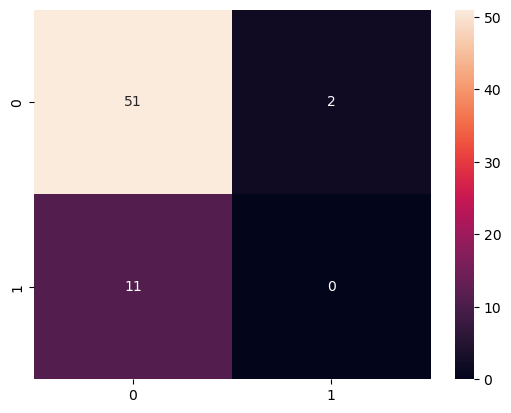

In [46]:
sns.heatmap(confusion_matrix(y_test,gtahmin), annot=True)

In [47]:
accuracy_score(y_test,btahmin)

0.828125

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()

def algo_test(x, y):
    modeller=[ b, l, d, r, gb, kn, ab]
    isimler=["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state = 42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl=[]

    print("Veriler hazır modeller deneniyor")
    for model in modeller:
        print(model, " modeli eğitiliyor!..")
        model=model.fit(x_train,y_train)
        tahmin=model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="micro"))
        recall.append(recall_score(y_test, tahmin, average="micro"))
        f1.append(f1_score(y_test, tahmin, average="micro"))
        print(confusion_matrix(y_test, tahmin))

    print("Eğitim tamamlandı.")
    
    metrics=pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"]=mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    model=metrics.iloc[0,-1]
    tahmin=model.predict(np.array(x_test) if model==kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("classification Report:")
    print(classification_report(y_test, tahmin))
    print("Diğer Modeller:")
    
    return metrics.drop("Model", axis=1)

In [51]:
algo_test(x,y)

Veriler hazır modeller deneniyor
BernoulliNB()  modeli eğitiliyor!..
[[53  0]
 [11  0]]
LogisticRegression()  modeli eğitiliyor!..
[[52  1]
 [11  0]]
DecisionTreeClassifier()  modeli eğitiliyor!..
[[42 11]
 [ 9  2]]
RandomForestClassifier()  modeli eğitiliyor!..
[[53  0]
 [11  0]]
GradientBoostingClassifier()  modeli eğitiliyor!..
[[48  5]
 [ 9  2]]
KNeighborsClassifier()  modeli eğitiliyor!..
[[51  2]
 [10  1]]
AdaBoostClassifier()  modeli eğitiliyor!..
[[51  2]
 [11  0]]
Eğitim tamamlandı.
En başarılı model:  BernoulliNB
Confusion Matrix:
[[53  0]
 [11  0]]
classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        53
           1       0.00      0.00      0.00        11

    accuracy                           0.83        64
   macro avg       0.41      0.50      0.45        64
weighted avg       0.69      0.83      0.75        64

Diğer Modeller:


,Accuracy,Precision,Recall,F1
BernoulliNB,0.828125,0.828125,0.828125,0.828125
RandomForestClassifier,0.828125,0.828125,0.828125,0.828125
LogisticRegression,0.812500,0.812500,0.812500,0.812500
KNeighborsClassifier,0.812500,0.812500,0.812500,0.812500
AdaBoostClassifier,0.796875,0.796875,0.796875,0.796875
GradientBoostingClassifier,0.781250,0.781250,0.781250,0.781250
DecisionTreeClassifier,0.687500,0.687500,0.687500,0.687500


In [52]:
sonuc=pd.DataFrame()

In [53]:
best_model=BernoulliNB()
best_model.fit(x_train, y_train)
tahmin=best_model.predict(x_test)

In [54]:
sonuc['Patient_Status']=tahmin

In [55]:
sonuc

,Patient_Status
0,0
1,0
2,0
3,0
4,0
...,...
59,0
60,0
61,0
62,0


In [56]:
best_model.fit(x, y)

#2. Feature listesini al
features = list(x.columns)

# 3. Modeli kaydet (joblib + pkl)
import joblib, pickle

# joblib 
joblib.dump(best_model, 'deadoralive.joblib')

# bundle (model + feature)
with open('deadoralive.pkl', 'wb') as f:
    pickle.dump({
        'model': best_model,
        'features': features
    }, f)

In [57]:
#Deep Learning

In [58]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [61]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(80, activation='relu', input_shape=(x_train.shape[1],)))  # giriş boyutu
model.add(Dense(120, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [65]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True)

In [66]:
history=model.fit(x,y,batch_size=32, validation_split=0.20,verbose=1, epochs=20,callbacks=[early_stop])

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7905 - loss: 0.5042 - val_accuracy: 0.8594 - val_loss: 0.4718
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7905 - loss: 0.4873 - val_accuracy: 0.8594 - val_loss: 0.4902
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7905 - loss: 0.4718 - val_accuracy: 0.8594 - val_loss: 0.5030
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7905 - loss: 0.4558 - val_accuracy: 0.8594 - val_loss: 0.5174
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7905 - loss: 0.4403 - val_accuracy: 0.8594 - val_loss: 0.5313
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7905 - loss: 0.4230 - val_accuracy: 0.8594 - val_loss: 0.5446
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7945 - loss: 0.4099 - val_accuracy: 0.8594 - val_loss: 0.5621
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8142 - loss: 0.3891 - val_accuracy: 0.8594 - val_loss: 0.5854


🇹🇷 Türkçe
Çalışma kapsamda farklı makine öğrenmesi algoritmaları uygulanmış ve modellerin performansları karşılaştırılmıştır. Elde edilen sonuçlara göre, en yüksek sınıflandırma başarısı %82 doğruluk oranı ile Bernoulli Naive Bayes (BernoulliNB) algoritması tarafından elde edilmiştir.
Modelimiz, derin öğrenme yaklaşımı kullanılarak eğitilmiş ve 20 epoch boyunca doğruluk ve kayıp değerleri izlenmiştir. Eğitim sürecinde modelin doğruluk oranı en yüksek %84,5’e ulaşırken, doğrulama setinde en yüksek doğruluk %85,9 olarak gözlemlenmiştir

🇬🇧 English
Various machine learning algorithms were implemented and their performances were comparatively evaluated. According to the results, the Bernoulli Naive Bayes (BernoulliNB) algorithm achieved the highest classification performance with an accuracy of 82%.
The deep learning model was trained over 20 epochs, with accuracy and loss monitored throughout the training process. The model achieved a maximum training accuracy of 84.5%, while the highest validation accuracy reached 85.9%.